# Module 10: Explainable AI (XAI) & Specialized Models


## Module outline

* **Step 1: Model-Specific Interpretability**
  * White-box models: linear/logistic coefficients, decision-tree rules, and node paths.
  * Tree feature importances: Mean Decrease in Impurity using Gini/Entropy, plus high-cardinality bias.
* **Step 2: Model-Agnostic Explainability & Feature Insights**
  * Permutation feature importance.
  * LIME: local sparse linear explanation around one prediction.
  * SHAP: additive feature contributions from Shapley values.
  * Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE).
* **Step 3: Survival Analysis (Time-to-Event Modeling)**
  * Censoring: right, left, and interval censoring.
  * Kaplan-Meier estimator.
  * Cox proportional hazards model.
  * Concordance index (C-index).


## Module 10 Learning Goal

A model prediction is not always enough. In many real projects, we also need to explain the prediction.

Examples:

- A bank may need to explain why a loan application was rejected.
- A doctor may need to know which medical measurements increased risk.
- A data scientist may need to prove the model is using sensible features.
- A business team may need to understand how changing one input affects the prediction.

This module separates explanations into two groups:

| Type | Meaning | Example |
|---|---|---|
| Model-specific | Explanation depends on the model structure | linear coefficients, tree rules |
| Model-agnostic | Explanation treats the model as a black box | permutation importance, LIME, SHAP, PDP, ICE |

The examples use a breast cancer classification dataset because interpretability matters in medical-style predictions and the features are numeric, which makes explanations easier to show.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 10

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
y_malignant = 1 - y

selected_features = [
    'mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean concavity', 'worst radius', 'worst texture',
    'worst perimeter', 'worst area', 'worst concavity'
]
X = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_malignant, test_size=0.25, random_state=42, stratify=y_malignant
)

print('Dataset rows:', X.shape[0])
print('Selected features:', X.shape[1])
print('Target used here: 1 = malignant, 0 = benign')
display(X_train.head())
display(pd.Series(y_train, name='Malignant').value_counts().sort_index().rename('count').to_frame())


Dataset rows: 569
Selected features: 11
Target used here: 1 = malignant, 0 = benign


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity,worst radius,worst texture,worst perimeter,worst area,worst concavity
251,11.50,18.45,73.28,407.4,0.09345,0.026380,12.97,22.46,83.12,508.9,0.08105
373,20.64,17.35,134.80,1335.0,0.09446,0.152700,25.37,23.17,166.80,1946.0,0.41590
211,11.84,18.94,75.51,428.0,0.08871,0.026690,13.30,24.99,85.22,546.3,0.14710
52,11.94,18.24,75.71,437.6,0.08261,0.019720,13.10,21.33,83.67,527.2,0.09203
315,12.49,16.85,79.19,481.6,0.08511,0.004473,13.34,19.71,84.48,544.2,0.01938


,count
Malignant,
0,267
1,159


### Step 1 - Model-Specific Interpretability

Model-specific interpretability uses something built into the model.

#### Linear and Logistic Regression Coefficients

A coefficient tells the direction and strength of a feature inside a linear formula.

For linear regression:

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \dots + b_px_p
$$

For logistic regression, the model first predicts **log-odds**:

$$
\log\left(\frac{p}{1-p}\right) = b_0 + b_1x_1 + b_2x_2 + \dots + b_px_p
$$

Then it converts log-odds into probability.

Simple meaning:

- positive coefficient: pushes prediction toward malignant risk in this notebook
- negative coefficient: pushes prediction away from malignant risk
- larger absolute value: stronger effect after scaling

Because features have different units, we use scaling before reading coefficients.


Logistic regression accuracy: 0.958
Logistic regression ROC-AUC: 0.996


,Feature,Coefficient_on_scaled_feature,Direction
6,worst radius,1.692,pushes toward malignant
9,worst area,1.574,pushes toward malignant
4,mean smoothness,1.341,pushes toward malignant
8,worst perimeter,1.276,pushes toward malignant
7,worst texture,1.148,pushes toward malignant
10,worst concavity,0.739,pushes toward malignant
1,mean texture,0.536,pushes toward malignant
3,mean area,0.516,pushes toward malignant
5,mean concavity,0.408,pushes toward malignant
0,mean radius,0.326,pushes toward malignant


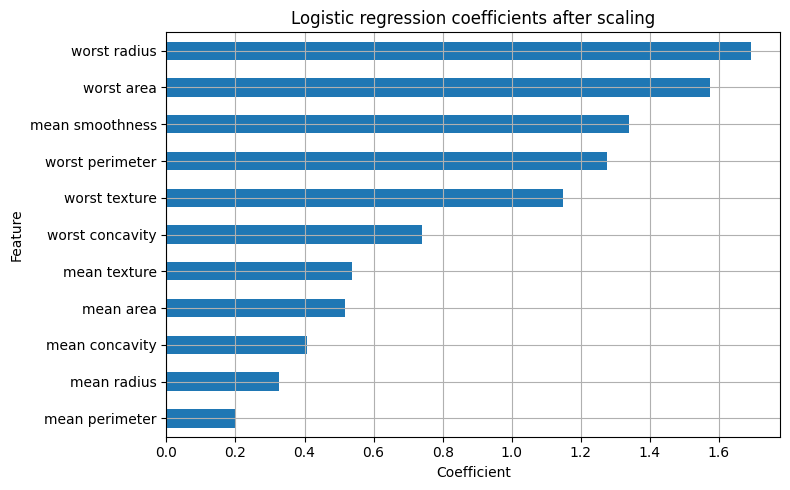

In [2]:
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, random_state=42))
])
log_model.fit(X_train, y_train)
prob = log_model.predict_proba(X_test)[:, 1]
pred = log_model.predict(X_test)

print('Logistic regression accuracy:', round(accuracy_score(y_test, pred), 3))
print('Logistic regression ROC-AUC:', round(roc_auc_score(y_test, prob), 3))

coef = log_model.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient_on_scaled_feature': coef,
    'Direction': np.where(coef > 0, 'pushes toward malignant', 'pushes toward benign')
}).sort_values('Coefficient_on_scaled_feature', key=lambda s: s.abs(), ascending=False)
display(coef_df.round(3))

coef_df.sort_values('Coefficient_on_scaled_feature').plot.barh(x='Feature', y='Coefficient_on_scaled_feature', legend=False, figsize=(8, 5))
plt.title('Logistic regression coefficients after scaling')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()


#### Decision Tree Rules and Node Paths

A decision tree is interpretable because a prediction follows a visible path.

Each internal node asks one question. Each leaf gives a prediction.

| Term | Meaning |
|---|---|
| Node | one question or one final prediction box |
| Split | condition that sends rows left or right |
| Leaf | final output of a path |
| Node path | sequence of decisions used for one row |

Trees are readable when they are shallow. A very deep tree can become hard to interpret.


Decision tree accuracy: 0.874
Readable tree rules:
|--- worst perimeter <= 112.80
|   |--- mean concavity <= 0.10
|   |   |--- mean area <= 696.25
|   |   |   |--- class: 0
|   |   |--- mean area >  696.25
|   |   |   |--- class: 1
|   |--- mean concavity >  0.10
|   |   |--- mean smoothness <= 0.11
|   |   |   |--- class: 0
|   |   |--- mean smoothness >  0.11
|   |   |   |--- class: 1
|--- worst perimeter >  112.80
|   |--- mean texture <= 14.95
|   |   |--- mean smoothness <= 0.11
|   |   |   |--- class: 0
|   |   |--- mean smoothness >  0.11
|   |   |   |--- class: 1
|   |--- mean texture >  14.95
|   |   |--- worst area <= 810.10
|   |   |   |--- class: 0
|   |   |--- worst area >  810.10
|   |   |   |--- class: 1



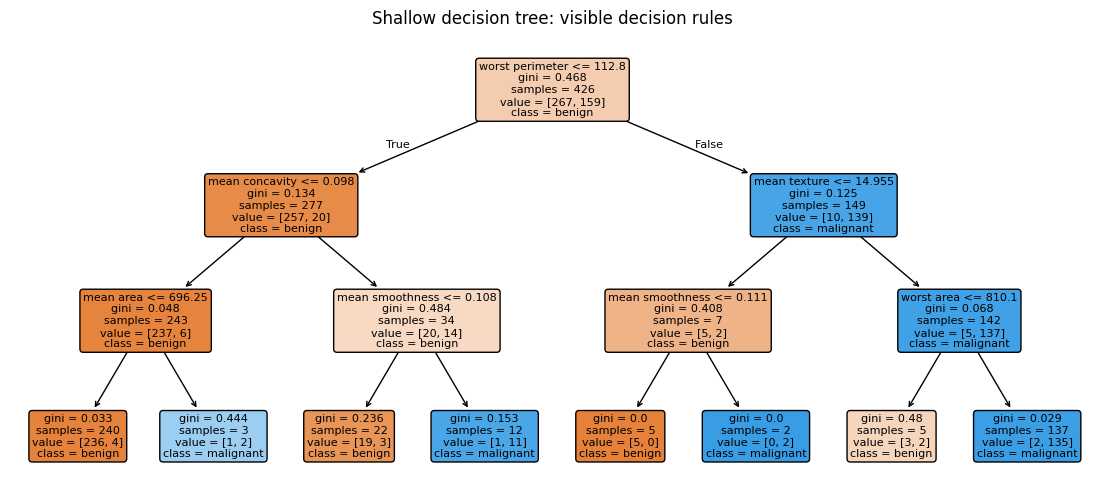

,Node,Rule,Decision
0,0,worst perimeter <= 112.80,value 151.70 goes right
1,8,mean texture <= 14.95,value 24.80 goes right
2,12,worst area <= 810.10,value 1332.00 goes right
3,14,Leaf node reached,final prediction


Prediction for this row: malignant


In [3]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
print('Decision tree accuracy:', round(accuracy_score(y_test, tree_pred), 3))

print('Readable tree rules:')
print(export_text(tree, feature_names=list(X.columns), decimals=2))

plt.figure(figsize=(14, 6))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=['benign', 'malignant'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Shallow decision tree: visible decision rules')
plt.show()

row = X_test.iloc[[0]]
node_indicator = tree.decision_path(row)
leaf_id = tree.apply(row)[0]
path_nodes = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
path_rows = []
for node_id in path_nodes:
    if leaf_id == node_id:
        path_rows.append({'Node': node_id, 'Rule': 'Leaf node reached', 'Decision': 'final prediction'})
    else:
        feature = X.columns[tree.tree_.feature[node_id]]
        threshold = tree.tree_.threshold[node_id]
        value = row.iloc[0][feature]
        direction = 'left' if value <= threshold else 'right'
        path_rows.append({'Node': node_id, 'Rule': f'{feature} <= {threshold:.2f}', 'Decision': f'value {value:.2f} goes {direction}'})

display(pd.DataFrame(path_rows))
print('Prediction for this row:', 'malignant' if tree.predict(row)[0] == 1 else 'benign')


#### Tree Feature Importance: Mean Decrease in Impurity

Tree models can calculate feature importance while training.

**Mean Decrease in Impurity (MDI):** a feature is important if it often creates splits that make child nodes purer than the parent node.

For classification, impurity is commonly measured using Gini or entropy.

Simple meaning:

```text
If a feature repeatedly creates clean splits, the tree gives it high importance.
```

Main limitation: MDI can be biased toward features with many possible split points or high-cardinality features. A continuous feature can receive high importance partly because it offers many split choices.


Random forest accuracy: 0.958
Random forest ROC-AUC: 0.995


,Feature,MDI_Tree_Importance
8,worst perimeter,0.2424
9,worst area,0.1657
6,worst radius,0.1641
2,mean perimeter,0.0887
5,mean concavity,0.0759
0,mean radius,0.0613
10,worst concavity,0.0555
3,mean area,0.0555
7,worst texture,0.0331
4,mean smoothness,0.0312


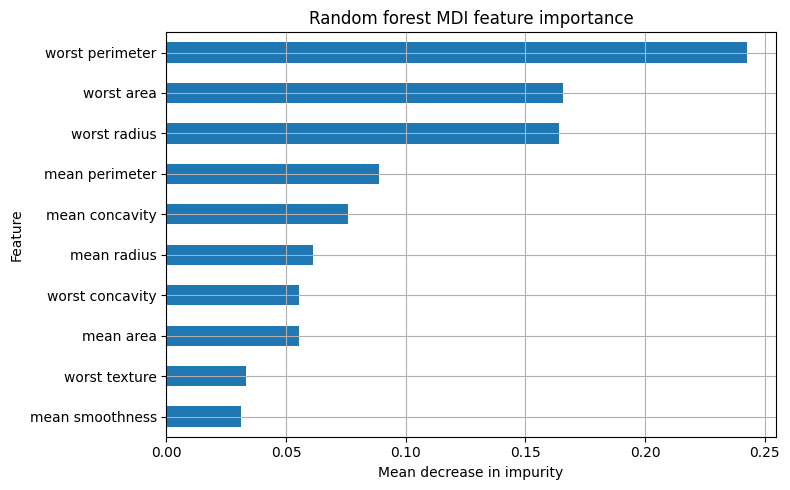

In [4]:
forest = RandomForestClassifier(n_estimators=300, random_state=42)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)
forest_prob = forest.predict_proba(X_test)[:, 1]

print('Random forest accuracy:', round(accuracy_score(y_test, forest_pred), 3))
print('Random forest ROC-AUC:', round(roc_auc_score(y_test, forest_prob), 3))

mdi_df = pd.DataFrame({
    'Feature': X.columns,
    'MDI_Tree_Importance': forest.feature_importances_
}).sort_values('MDI_Tree_Importance', ascending=False)
display(mdi_df.round(4))

mdi_df.head(10).sort_values('MDI_Tree_Importance').plot.barh(x='Feature', y='MDI_Tree_Importance', legend=False)
plt.title('Random forest MDI feature importance')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()


### Step 2 - Model-Agnostic Explainability and Feature Insights

Model-agnostic methods do not need to know the internal structure of the model. They ask questions by changing inputs and watching how predictions change.


#### Permutation Feature Importance

**Definition:** permutation importance measures how much performance drops after shuffling one feature.

Process:

1. Measure normal model performance.
2. Shuffle one feature column in the validation data.
3. Measure performance again.
4. The drop is the importance of that feature.

Permutation importance is usually easier to trust than tree impurity importance because it measures actual performance impact. But it can still be affected when features are highly correlated.


,Feature,Mean_ROC_AUC_Drop_When_Shuffled,Std
6,worst radius,0.0170,0.0063
9,worst area,0.0161,0.0054
8,worst perimeter,0.0155,0.0054
3,mean area,0.0050,0.0037
10,worst concavity,0.0046,0.0030
5,mean concavity,0.0043,0.0035
7,worst texture,0.0033,0.0016
1,mean texture,0.0019,0.0010
0,mean radius,0.0010,0.0029
2,mean perimeter,0.0009,0.0027


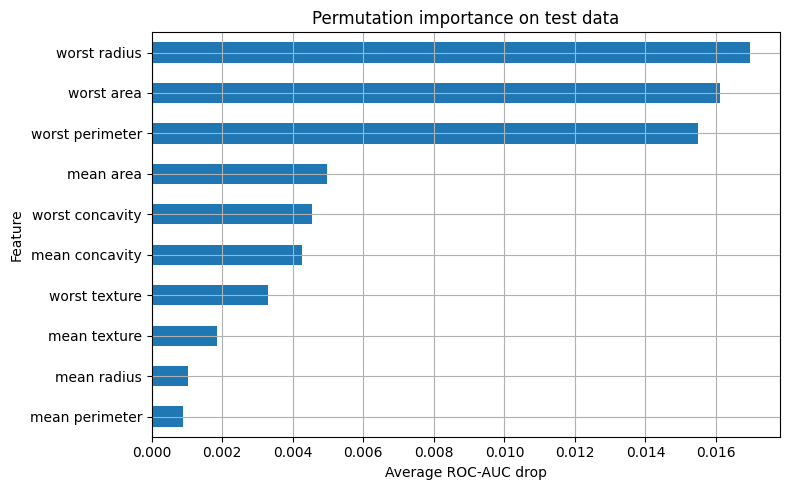

In [5]:
perm = permutation_importance(
    forest, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc'
)
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_ROC_AUC_Drop_When_Shuffled': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Mean_ROC_AUC_Drop_When_Shuffled', ascending=False)

display(perm_df.round(4))
perm_df.head(10).sort_values('Mean_ROC_AUC_Drop_When_Shuffled').plot.barh(
    x='Feature', y='Mean_ROC_AUC_Drop_When_Shuffled', legend=False
)
plt.title('Permutation importance on test data')
plt.xlabel('Average ROC-AUC drop')
plt.tight_layout()
plt.show()


#### LIME: Local Interpretable Model-Agnostic Explanations

**Definition:** LIME explains one prediction by building a simple model near that one row.

Process:

1. Choose one row to explain.
2. Create many small variations around that row.
3. Get the black-box model prediction for each variation.
4. Give higher weight to variations close to the original row.
5. Fit a simple sparse linear model on those weighted variations.
6. Read the local coefficients as the explanation.

The code below implements the core LIME idea without requiring the external `lime` package.


In [6]:
from sklearn.metrics.pairwise import euclidean_distances

row_id = 0
row = X_test.iloc[[row_id]]
scaler = StandardScaler().fit(X_train)
row_scaled = scaler.transform(row)[0]

n_samples = 1200
noise = np.random.default_rng(42).normal(0, 0.35, size=(n_samples, X.shape[1]))
local_scaled = row_scaled + noise
local_points = pd.DataFrame(scaler.inverse_transform(local_scaled), columns=X.columns)
black_box_pred = forest.predict_proba(local_points)[:, 1]

dist = euclidean_distances(local_scaled, row_scaled.reshape(1, -1)).ravel()
kernel_width = np.sqrt(X.shape[1]) * 0.75
weights = np.exp(-(dist ** 2) / (kernel_width ** 2))

lime_model = LinearRegression()
lime_model.fit(local_scaled, black_box_pred, sample_weight=weights)

lime_df = pd.DataFrame({
    'Feature': X.columns,
    'Local_LIME_like_Coefficient': lime_model.coef_,
    'Patient_Value': row.iloc[0].values
}).sort_values('Local_LIME_like_Coefficient', key=lambda s: s.abs(), ascending=False)

print('Black-box predicted malignant probability for this row:', round(forest.predict_proba(row)[0, 1], 3))
display(lime_df.head(8).round(3))


Black-box predicted malignant probability for this row: 1.0


,Feature,Local_LIME_like_Coefficient,Patient_Value
9,worst area,0.021,1332.000
10,worst concavity,0.015,0.364
6,worst radius,0.011,20.960
5,mean concavity,0.003,0.206
3,mean area,0.003,1123.000
0,mean radius,-0.002,19.170
1,mean texture,0.002,24.800
2,mean perimeter,0.001,132.400


#### SHAP: Additive Feature Contributions

**Definition:** SHAP explains a prediction by splitting the prediction difference among features.

The explanation has an additive form:

$$
\text{prediction} = \text{baseline} + \phi_1 + \phi_2 + \dots + \phi_p
$$

- baseline: average model output before looking at this row
- $\phi_j$: contribution from feature $j$
- positive contribution: pushes prediction upward
- negative contribution: pushes prediction downward

The exact SHAP algorithm uses Shapley values from cooperative game theory. The code below gives a small teaching approximation to show the additive contribution idea before using a SHAP library.


In [7]:
baseline = X_train.mean().to_frame().T
baseline_pred = forest.predict_proba(baseline)[0, 1]
row = X_test.iloc[[0]]
row_pred = forest.predict_proba(row)[0, 1]

contrib_rows = []
for feature in X.columns:
    modified = baseline.copy()
    modified[feature] = row.iloc[0][feature]
    modified_pred = forest.predict_proba(modified)[0, 1]
    contrib_rows.append({
        'Feature': feature,
        'Baseline_Value': baseline.iloc[0][feature],
        'Row_Value': row.iloc[0][feature],
        'One_Feature_Contribution_Approx': modified_pred - baseline_pred
    })

contrib_df = pd.DataFrame(contrib_rows).sort_values('One_Feature_Contribution_Approx', key=lambda s: s.abs(), ascending=False)
print('Baseline malignant probability:', round(baseline_pred, 3))
print('Actual row malignant probability:', round(row_pred, 3))
display(contrib_df.head(10).round(4))


Baseline malignant probability: 0.297
Actual row malignant probability: 1.0


,Feature,Baseline_Value,Row_Value,One_Feature_Contribution_Approx
8,worst perimeter,107.9005,151.7000,0.3500
6,worst radius,16.3661,20.9600,0.2800
5,mean concavity,0.0888,0.2065,0.2067
3,mean area,660.0761,1123.0000,0.1533
0,mean radius,14.1677,19.1700,0.0967
9,worst area,892.9528,1332.0000,0.0900
10,worst concavity,0.2738,0.3639,0.0867
2,mean perimeter,92.1929,132.4000,0.0833
1,mean texture,19.3997,24.8000,0.0700
7,worst texture,25.8444,29.9400,0.0700


#### PDP and ICE

**Partial Dependence Plot (PDP):** shows the average model prediction when one feature is forced to different values.

**Individual Conditional Expectation (ICE):** shows one curve per row.

PDP is global because it averages many rows. ICE is local because it keeps individual rows visible.

Warning: PDP can be misleading when features are strongly correlated, because it may test unrealistic feature combinations.


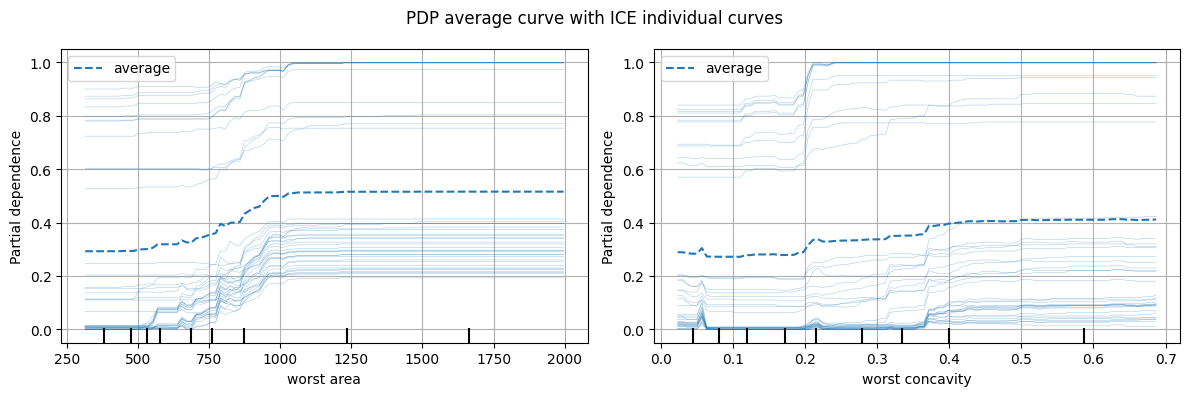

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    forest, X_test, features=['worst area'], kind='both', subsample=40,
    random_state=42, ax=ax[0]
)
PartialDependenceDisplay.from_estimator(
    forest, X_test, features=['worst concavity'], kind='both', subsample=40,
    random_state=42, ax=ax[1]
)
plt.suptitle('PDP average curve with ICE individual curves')
plt.tight_layout()
plt.show()


### Step 3 - Survival Analysis: Time-to-Event Modeling

Normal classification asks whether an event happens. Survival analysis asks **when** it happens.

| Problem | Event | Time |
|---|---|---|
| Employee attrition | employee leaves | months until leaving |
| Machine maintenance | machine fails | hours until failure |
| Medical study | patient relapse | months until relapse |
| Subscription business | customer cancels | days until cancellation |

The special challenge is censoring: sometimes we know the event has not happened yet, but we do not know when it will happen in the future.


#### Censoring

Censoring means the exact event time is partly unknown.

| Type | Meaning | Example |
|---|---|---|
| Right-censored | event has not happened by the last observation time | employee still works after 24 months |
| Left-censored | event happened before observation began | machine was already failed at first inspection |
| Interval-censored | event happened between two observation times | patient was healthy in January and relapsed by March |

Most beginner survival models start with right-censored data.


In [9]:
rng = np.random.default_rng(42)
n = 120
age = rng.integers(25, 61, size=n)
workload = rng.normal(50, 12, size=n).clip(20, 90)
training_hours = rng.normal(18, 7, size=n).clip(0, 40)

risk_score = 0.035 * (age - 40) + 0.04 * (workload - 50) - 0.05 * (training_hours - 18)
base_time = rng.weibull(1.5, size=n) * 30
event_time = base_time * np.exp(-risk_score)
censor_time = rng.uniform(10, 60, size=n)
observed_time = np.minimum(event_time, censor_time)
event_observed = (event_time <= censor_time).astype(int)

surv = pd.DataFrame({
    'Age': age,
    'Workload_Index': workload.round(1),
    'Training_Hours': training_hours.round(1),
    'Observed_Months': observed_time.round(1),
    'Event_Observed': event_observed
})

display(surv.head(10))
display(surv['Event_Observed'].value_counts().rename(index={0:'right-censored',1:'event observed'}).to_frame('count'))


,Age,Workload_Index,Training_Hours,Observed_Months,Event_Observed
0,28,39.6,17.2,12.0,0
1,52,61.6,20.0,7.7,1
2,48,29.8,27.1,16.2,0
3,40,46.0,19.5,16.7,1
4,40,52.0,15.1,24.4,1
5,55,57.0,25.7,22.2,1
6,28,58.5,21.0,26.0,1
7,50,59.5,28.8,17.6,1
8,32,45.8,19.3,27.1,1
9,28,44.5,9.4,19.7,0


,count
Event_Observed,
event observed,72
right-censored,48


#### Kaplan-Meier Estimator

**Definition:** Kaplan-Meier estimates the survival probability over time without using features.

Survival probability means:

```text
P(event has not happened after time t)
```

Formula at each event time:

$$
S(t) = S(t_{previous}) \times \left(1 - \frac{d_t}{n_t}\right)
$$

Where:

- $S(t)$ = survival probability after time $t$
- $d_t$ = number of events at time $t$
- $n_t$ = number of people/items still at risk just before time $t$


,Time,At_Risk,Events,Censored_at_time,Survival_Probability
0,0.9,120,1,0,0.992
1,1.3,119,1,0,0.983
2,1.5,118,1,0,0.975
3,2.3,117,1,0,0.967
4,2.7,116,1,0,0.958
5,3.1,115,1,0,0.950
6,3.4,114,2,0,0.933
7,3.9,112,1,0,0.925
8,4.6,111,1,0,0.917
9,4.8,110,1,0,0.908


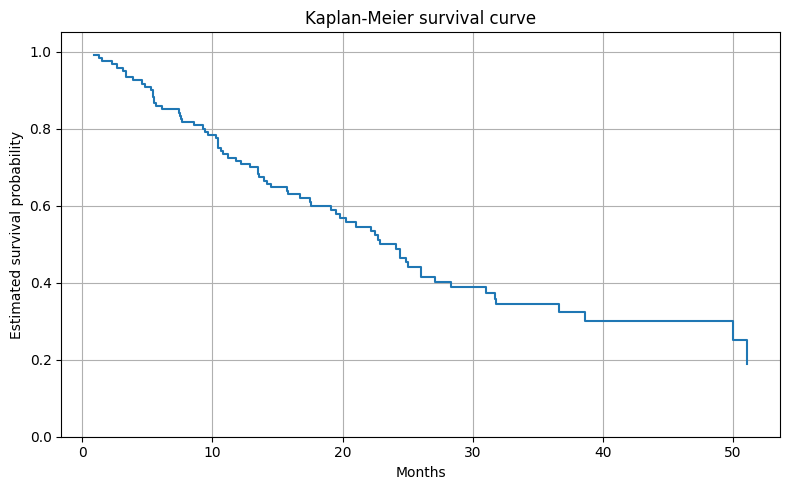

In [10]:
def kaplan_meier_table(time, event):
    df_km = pd.DataFrame({'time': time, 'event': event}).sort_values('time')
    survival = 1.0
    rows = []
    for t in sorted(df_km.loc[df_km['event'] == 1, 'time'].unique()):
        at_risk = (df_km['time'] >= t).sum()
        events = ((df_km['time'] == t) & (df_km['event'] == 1)).sum()
        censored = ((df_km['time'] == t) & (df_km['event'] == 0)).sum()
        survival *= (1 - events / at_risk)
        rows.append({'Time': t, 'At_Risk': at_risk, 'Events': events, 'Censored_at_time': censored, 'Survival_Probability': survival})
    return pd.DataFrame(rows)

km = kaplan_meier_table(surv['Observed_Months'], surv['Event_Observed'])
display(km.head(12).round(3))

plt.step(km['Time'], km['Survival_Probability'], where='post')
plt.ylim(0, 1.05)
plt.xlabel('Months')
plt.ylabel('Estimated survival probability')
plt.title('Kaplan-Meier survival curve')
plt.tight_layout()
plt.show()


#### Cox Proportional Hazards Model

**Definition:** the Cox model connects features to the hazard rate.

Hazard means the current risk of the event at time $t$, given that the person/item has survived until time $t$.

Cox model form:

$$
h(t|x) = h_0(t) \times \exp(b_1x_1 + b_2x_2 + \dots + b_px_p)
$$

Simple meaning:

- $h_0(t)$ is the baseline hazard over time.
- The exponential part changes the hazard using features.
- If a hazard ratio is above 1, risk is higher.
- If a hazard ratio is below 1, risk is lower.

**Proportional hazards assumption:** the ratio between two people's hazards stays constant over time.

This notebook avoids installing a survival package. The code below trains a simple risk ranking model as a teaching approximation. In a production survival project, use a survival library such as `lifelines`, `scikit-survival`, or a validated survival modeling tool.


In [11]:
model_df = surv.copy()
event_rows = model_df['Event_Observed'] == 1
risk_target = np.zeros(len(model_df))
risk_target[event_rows] = 1 / model_df.loc[event_rows, 'Observed_Months']

risk_features = ['Age', 'Workload_Index', 'Training_Hours']
risk_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
risk_model.fit(model_df[risk_features], risk_target)
model_df['Predicted_Risk_Score'] = risk_model.predict(model_df[risk_features])

coef = risk_model.named_steps['model'].coef_
risk_coef_df = pd.DataFrame({
    'Feature': risk_features,
    'Risk_Model_Coefficient': coef,
    'Simple_Meaning': np.where(coef > 0, 'higher value increases predicted risk', 'higher value lowers predicted risk')
})
display(risk_coef_df.round(4))
display(model_df.sort_values('Predicted_Risk_Score', ascending=False).head(10).round(3))


,Feature,Risk_Model_Coefficient,Simple_Meaning
0,Age,0.0189,higher value increases predicted risk
1,Workload_Index,0.0454,higher value increases predicted risk
2,Training_Hours,-0.0248,higher value lowers predicted risk


,Age,Workload_Index,Training_Hours,Observed_Months,Event_Observed,Predicted_Risk_Score
81,40,85.0,8.4,1.5,1,0.261
60,58,69.2,10.6,9.7,1,0.222
80,58,74.0,17.1,13.5,1,0.219
104,53,75.5,24.5,3.4,1,0.190
45,59,58.9,10.4,7.4,1,0.182
65,36,66.3,7.7,3.4,1,0.178
97,49,71.2,20.7,15.7,1,0.177
106,53,60.1,10.2,14.5,1,0.176
50,52,60.1,12.0,7.5,1,0.168
58,51,52.8,3.0,2.3,1,0.167


#### Concordance Index (C-index)

**Definition:** C-index checks whether predicted risk correctly orders event times.

Simple meaning:

```text
If person A had the event earlier than person B,
did the model give person A a higher risk score?
```

| Value | Meaning |
|---|---|
| 0.5 | random ordering |
| above 0.5 | better than random |
| 1.0 | perfect ordering |


In [12]:
def simple_c_index(time, event, risk):
    comparable = 0
    concordant = 0
    tied = 0
    time = np.asarray(time)
    event = np.asarray(event)
    risk = np.asarray(risk)
    for i in range(len(time)):
        for j in range(len(time)):
            if time[i] < time[j] and event[i] == 1:
                comparable += 1
                if risk[i] > risk[j]:
                    concordant += 1
                elif risk[i] == risk[j]:
                    tied += 1
    return (concordant + 0.5 * tied) / comparable, comparable

cidx, comparable_pairs = simple_c_index(
    model_df['Observed_Months'],
    model_df['Event_Observed'],
    model_df['Predicted_Risk_Score']
)
print('Comparable pairs:', comparable_pairs)
print('Simple C-index:', round(cidx, 3))


Comparable pairs: 5298
Simple C-index: 0.725


## Module 10 Summary

- Linear/logistic coefficients explain direction and strength after scaling.
- Decision trees can be explained by reading rules and node paths.
- Tree impurity importance is useful but can be biased toward high-cardinality or many-split features.
- Permutation importance measures performance drop after shuffling a feature.
- LIME explains one prediction with a local simple model.
- SHAP explains predictions as baseline plus additive feature contributions.
- PDP shows average feature effect; ICE shows individual feature effect.
- Survival analysis models time until event, handles censoring, uses Kaplan-Meier curves, Cox hazard ideas, and C-index ranking evaluation.
